ResNet50

Device: cuda
Test classes (theo ImageFolder): ['Acne', 'Actinic_Keratosis', 'Benign_tumors', 'Bullous', 'Candidiasis', 'DrugEruption', 'Eczema', 'Infestations_Bites', 'Lichen', 'Lupus', 'Moles', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'SkinCancer', 'Sun_Sunlight_Damage', 'Tinea', 'Unknown_Normal', 'Vascular_Tumors', 'Vasculitis', 'Vitiligo', 'Warts']
Num test samples: 179
Checkpoint type: <class 'collections.OrderedDict'>


C:\Users\letra\AppData\Local\Temp\ipykernel_28332\670482941.py:99: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location=device)


Built ResNet50 with num_classes = 22


Evaluate Test:   0%|          | 0/6 [00:00<?, ?it/s]C:\Users\letra\AppData\Local\Temp\ipykernel_28332\670482941.py:144: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Evaluate Test: 100%|██████████| 6/6 [00:04<00:00,  1.46it/s]



===== CLASSIFICATION REPORT (TEST) =====
                     precision    recall  f1-score   support

               Acne     0.9167    1.0000    0.9565        11
  Actinic_Keratosis     1.0000    0.5714    0.7273         7
      Benign_tumors     0.8182    0.9000    0.8571        10
            Bullous     0.7778    1.0000    0.8750         7
        Candidiasis     0.9000    0.9000    0.9000        10
       DrugEruption     1.0000    1.0000    1.0000         6
             Eczema     0.8750    0.7778    0.8235         9
 Infestations_Bites     0.8000    0.8000    0.8000         5
             Lichen     1.0000    0.5000    0.6667         6
              Lupus     0.6000    0.7500    0.6667         4
              Moles     1.0000    1.0000    1.0000         8
          Psoriasis     0.8333    0.7143    0.7692         7
            Rosacea     0.8889    0.8889    0.8889         9
  Seborrh_Keratoses     1.0000    1.0000    1.0000         7
         SkinCancer     1.0000    0.5000  

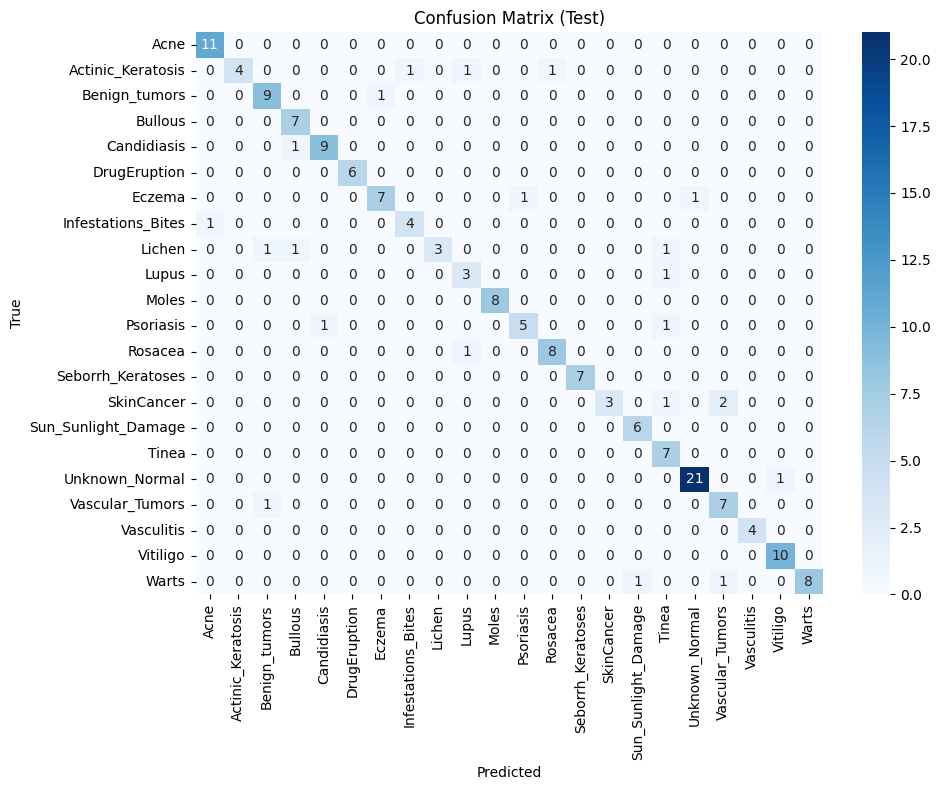

In [4]:
# ===================== 0) IMPORT =====================
import os
import numpy as np
import torch
import torch.nn as nn
from collections import OrderedDict

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast
from tqdm.auto import tqdm

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ===================== 1) CONFIG =====================
CKPT_PATH = r"E:\archive\PiplineCode pretrain=True\resnet50_pretrained_fulloption.pth"   # <-- sửa path file đã train
TEST_DIR  = r"E:\archive\SkinDisease\AnhTest"               # <-- sửa path folder test

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===================== 2) TRANSFORM TEST =====================
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# ===================== 3) LOAD TEST DATA (ImageFolder) =====================
if not os.path.isdir(TEST_DIR):
    raise FileNotFoundError(f"TEST_DIR không tồn tại: {TEST_DIR}")

test_ds = datasets.ImageFolder(TEST_DIR, transform=test_tfms)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda")
)

class_names = list(test_ds.classes)
print("Test classes (theo ImageFolder):", class_names)
print("Num test samples:", len(test_ds))

# ===================== 4) HÀM TRÍCH STATE_DICT (CHỊU NHIỀU FORMAT) =====================
def strip_prefix(state_dict, prefixes=("module.", "model.", "net.", "backbone.")):
    new_sd = OrderedDict()
    for k, v in state_dict.items():
        nk = k
        for p in prefixes:
            if nk.startswith(p):
                nk = nk[len(p):]
        new_sd[nk] = v
    return new_sd

def extract_state_dict(ckpt_obj):
    # Case A: torch.save(model, path) => ckpt là nn.Module
    if isinstance(ckpt_obj, nn.Module):
        return ckpt_obj.state_dict()

    # Case B: checkpoint dict chứa state_dict ở key phổ biến
    if isinstance(ckpt_obj, dict):
        for key in ["state_dict", "model_state_dict", "model_state", "model", "net", "network", "weights"]:
            if key in ckpt_obj:
                v = ckpt_obj[key]
                if isinstance(v, nn.Module):
                    return v.state_dict()
                if isinstance(v, dict):
                    return v

        # Case C: torch.save(model.state_dict(), path) => ckpt chính là state_dict
        if len(ckpt_obj) > 0 and all(torch.is_tensor(v) for v in ckpt_obj.values()):
            return ckpt_obj

    raise ValueError(
        f"Không trích được state_dict. type={type(ckpt_obj)}; "
        f"keys={list(ckpt_obj.keys())[:30] if isinstance(ckpt_obj, dict) else 'N/A'}"
    )

def infer_num_classes_from_state_dict(sd):
    # sau khi strip prefix
    for k in ["fc.weight", "classifier.weight"]:
        if k in sd and hasattr(sd[k], "shape") and len(sd[k].shape) == 2:
            return int(sd[k].shape[0])
    return None

# ===================== 5) LOAD CHECKPOINT + BUILD MODEL =====================
if not os.path.isfile(CKPT_PATH):
    raise FileNotFoundError(f"CKPT_PATH không tồn tại: {CKPT_PATH}")

ckpt = torch.load(CKPT_PATH, map_location=device)
print("Checkpoint type:", type(ckpt))

# Nếu ckpt là cả model => dùng luôn
if isinstance(ckpt, nn.Module):
    model = ckpt
    model.to(device).eval()
    print("Loaded full model object from checkpoint.")
else:
    sd = extract_state_dict(ckpt)
    sd = strip_prefix(sd)

    # ưu tiên suy ra số lớp từ fc.weight trong checkpoint (đúng nhất)
    inferred_classes = infer_num_classes_from_state_dict(sd)
    num_classes = inferred_classes if inferred_classes is not None else len(class_names)

    # build ResNet50 đúng số lớp
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    # load weights (strict=False để chịu các key thừa/thiếu nhẹ)
    msg = model.load_state_dict(sd, strict=False)
    model.to(device).eval()

    print(f"Built ResNet50 with num_classes = {num_classes}")
    if len(msg.missing_keys) or len(msg.unexpected_keys):
        print("Missing keys (first 20):", msg.missing_keys[:20], "..." if len(msg.missing_keys) > 20 else "")
        print("Unexpected keys (first 20):", msg.unexpected_keys[:20], "..." if len(msg.unexpected_keys) > 20 else "")

# nếu checkpoint có lưu class_names thì ưu tiên dùng cho report (để khớp thứ tự lúc train)
if isinstance(ckpt, dict) and "class_names" in ckpt and isinstance(ckpt["class_names"], (list, tuple)):
    if len(ckpt["class_names"]) == getattr(model.fc, "out_features", len(class_names)):
        class_names = list(ckpt["class_names"])
        print("Using class_names from checkpoint.")

# ===================== 6) EVALUATE TEST (AMP + PROGRESS BAR) =====================
y_true, y_pred = [], []

use_amp = (device.type == "cuda")
with torch.no_grad():
    pbar = tqdm(test_loader, desc="Evaluate Test", leave=True)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(enabled=use_amp):
            logits = model(images)

        preds = torch.argmax(logits, dim=1)

        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ===================== 7) CLASSIFICATION REPORT =====================
print("\n===== CLASSIFICATION REPORT (TEST) =====")
# nếu số lớp model khác số class_names hiện có, tự tạo tên dạng Class_i
if len(class_names) != len(np.unique(y_true)) and hasattr(model, "fc") and isinstance(model.fc, nn.Linear):
    out_c = model.fc.out_features
    if len(class_names) != out_c:
        class_names = [f"Class_{i}" for i in range(out_c)]

print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

# ===================== 8) CONFUSION MATRIX + PLOT =====================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


DenseNet121

Device: cuda
Test classes (theo ImageFolder): ['Acne', 'Actinic_Keratosis', 'Benign_tumors', 'Bullous', 'Candidiasis', 'DrugEruption', 'Eczema', 'Infestations_Bites', 'Lichen', 'Lupus', 'Moles', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'SkinCancer', 'Sun_Sunlight_Damage', 'Tinea', 'Unknown_Normal', 'Vascular_Tumors', 'Vasculitis', 'Vitiligo', 'Warts']
Num test samples: 179
Checkpoint type: <class 'collections.OrderedDict'>


C:\Users\letra\AppData\Local\Temp\ipykernel_28332\3179304887.py:99: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location=device)


Built DenseNet121 with num_classes = 22


Evaluate Test:   0%|          | 0/6 [00:00<?, ?it/s]C:\Users\letra\AppData\Local\Temp\ipykernel_28332\3179304887.py:144: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Evaluate Test: 100%|██████████| 6/6 [00:04<00:00,  1.48it/s]



===== CLASSIFICATION REPORT (TEST) =====
                     precision    recall  f1-score   support

               Acne     1.0000    1.0000    1.0000        11
  Actinic_Keratosis     1.0000    0.7143    0.8333         7
      Benign_tumors     0.9000    0.9000    0.9000        10
            Bullous     0.8750    1.0000    0.9333         7
        Candidiasis     1.0000    0.9000    0.9474        10
       DrugEruption     1.0000    1.0000    1.0000         6
             Eczema     0.9000    1.0000    0.9474         9
 Infestations_Bites     0.8333    1.0000    0.9091         5
             Lichen     0.8333    0.8333    0.8333         6
              Lupus     0.6667    0.5000    0.5714         4
              Moles     0.8889    1.0000    0.9412         8
          Psoriasis     0.8750    1.0000    0.9333         7
            Rosacea     1.0000    1.0000    1.0000         9
  Seborrh_Keratoses     1.0000    0.8571    0.9231         7
         SkinCancer     0.8333    0.8333  

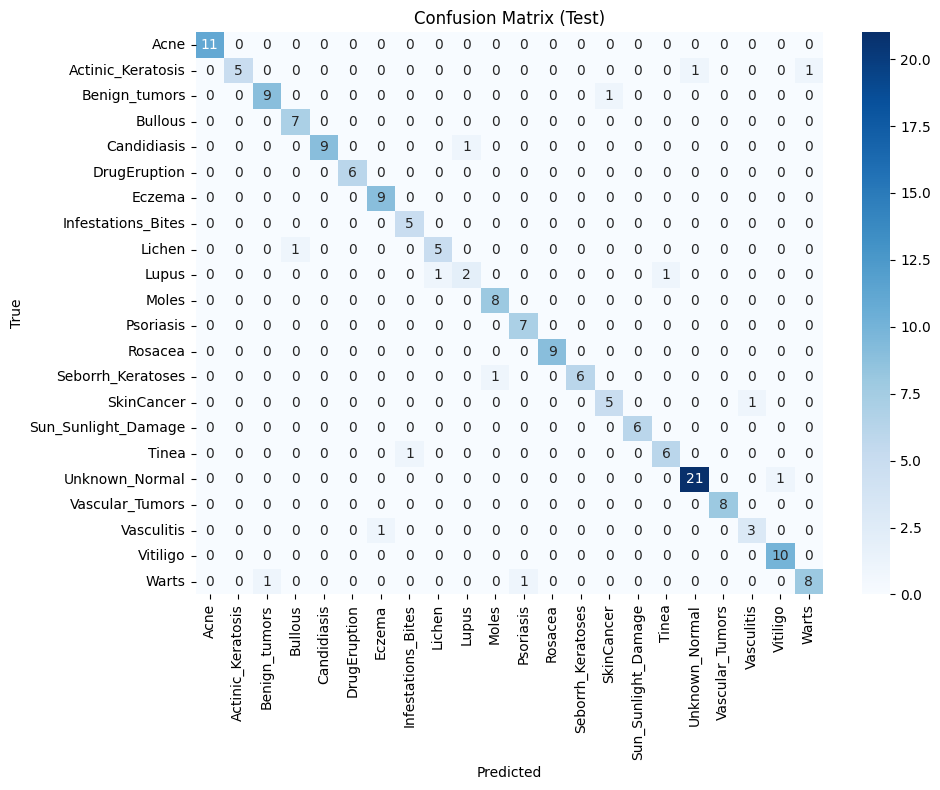

In [18]:
# ===================== 0) IMPORT =====================
import os
import numpy as np
import torch
import torch.nn as nn
from collections import OrderedDict

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast
from tqdm.auto import tqdm

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ===================== 1) CONFIG =====================
CKPT_PATH = r"E:\archive\PiplineCode pretrain=True\densenet121_pretrained_fulloption.pth" 
TEST_DIR  = r"E:\archive\SkinDisease\AnhTest"                                             

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===================== 2) TRANSFORM TEST =====================
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# ===================== 3) LOAD TEST DATA (ImageFolder) =====================
if not os.path.isdir(TEST_DIR):
    raise FileNotFoundError(f"TEST_DIR không tồn tại: {TEST_DIR}")

test_ds = datasets.ImageFolder(TEST_DIR, transform=test_tfms)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda")
)

class_names = list(test_ds.classes)
print("Test classes (theo ImageFolder):", class_names)
print("Num test samples:", len(test_ds))

# ===================== 4) HÀM TRÍCH STATE_DICT (CHỊU NHIỀU FORMAT) =====================
def strip_prefix(state_dict, prefixes=("module.", "model.", "net.", "backbone.")):
    new_sd = OrderedDict()
    for k, v in state_dict.items():
        nk = k
        for p in prefixes:
            if nk.startswith(p):
                nk = nk[len(p):]
        new_sd[nk] = v
    return new_sd

def extract_state_dict(ckpt_obj):
    # Case A: torch.save(model, path) => ckpt là nn.Module
    if isinstance(ckpt_obj, nn.Module):
        return ckpt_obj.state_dict()

    # Case B: checkpoint dict chứa state_dict ở key phổ biến
    if isinstance(ckpt_obj, dict):
        for key in ["state_dict", "model_state_dict", "model_state", "model", "net", "network", "weights"]:
            if key in ckpt_obj:
                v = ckpt_obj[key]
                if isinstance(v, nn.Module):
                    return v.state_dict()
                if isinstance(v, dict):
                    return v

        # Case C: torch.save(model.state_dict(), path) => ckpt chính là state_dict
        if len(ckpt_obj) > 0 and all(torch.is_tensor(v) for v in ckpt_obj.values()):
            return ckpt_obj

    raise ValueError(
        f"Không trích được state_dict. type={type(ckpt_obj)}; "
        f"keys={list(ckpt_obj.keys())[:30] if isinstance(ckpt_obj, dict) else 'N/A'}"
    )

def infer_num_classes_from_state_dict(sd):
    # DenseNet thường là "classifier.weight", ResNet là "fc.weight"
    for k in ["classifier.weight", "fc.weight"]:
        if k in sd and hasattr(sd[k], "shape") and len(sd[k].shape) == 2:
            return int(sd[k].shape[0])
    return None

# ===================== 5) LOAD CHECKPOINT + BUILD MODEL (DENSENET121) =====================
if not os.path.isfile(CKPT_PATH):
    raise FileNotFoundError(f"CKPT_PATH không tồn tại: {CKPT_PATH}")

ckpt = torch.load(CKPT_PATH, map_location=device)
print("Checkpoint type:", type(ckpt))

# Nếu ckpt là cả model => dùng luôn
if isinstance(ckpt, nn.Module):
    model = ckpt
    model.to(device).eval()
    print("Loaded full model object from checkpoint.")
else:
    sd = extract_state_dict(ckpt)
    sd = strip_prefix(sd)

    # ưu tiên suy ra số lớp từ classifier.weight / fc.weight trong checkpoint (đúng nhất)
    inferred_classes = infer_num_classes_from_state_dict(sd)
    num_classes = inferred_classes if inferred_classes is not None else len(class_names)

    # build DenseNet121 đúng số lớp
    model = models.densenet121(weights=None)
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    # load weights (strict=False để chịu các key thừa/thiếu nhẹ)
    msg = model.load_state_dict(sd, strict=False)
    model.to(device).eval()

    print(f"Built DenseNet121 with num_classes = {num_classes}")
    if len(msg.missing_keys) or len(msg.unexpected_keys):
        print("Missing keys (first 20):", msg.missing_keys[:20], "..." if len(msg.missing_keys) > 20 else "")
        print("Unexpected keys (first 20):", msg.unexpected_keys[:20], "..." if len(msg.unexpected_keys) > 20 else "")

# nếu checkpoint có lưu class_names thì ưu tiên dùng cho report (để khớp thứ tự lúc train)
if isinstance(ckpt, dict) and "class_names" in ckpt and isinstance(ckpt["class_names"], (list, tuple)):
    if len(ckpt["class_names"]) == getattr(model.classifier, "out_features", len(class_names)):
        class_names = list(ckpt["class_names"])
        print("Using class_names from checkpoint.")

# ===================== 6) EVALUATE TEST (AMP + PROGRESS BAR) =====================
y_true, y_pred = [], []

use_amp = (device.type == "cuda")
with torch.no_grad():
    pbar = tqdm(test_loader, desc="Evaluate Test", leave=True)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(enabled=use_amp):
            logits = model(images)

        preds = torch.argmax(logits, dim=1)

        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ===================== 7) CLASSIFICATION REPORT =====================
print("\n===== CLASSIFICATION REPORT (TEST) =====")
# nếu số lớp model khác số class_names hiện có, tự tạo tên dạng Class_i
if hasattr(model, "classifier") and isinstance(model.classifier, nn.Linear):
    out_c = model.classifier.out_features
    if len(class_names) != out_c:
        class_names = [f"Class_{i}" for i in range(out_c)]

print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

# ===================== 8) CONFUSION MATRIX + PLOT =====================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


MobiNet_V3

C:\Users\letra\AppData\Local\Temp\ipykernel_28332\4250371391.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location=device)


Device: cuda
Test classes (theo ImageFolder): ['Acne', 'Actinic_Keratosis', 'Benign_tumors', 'Bullous', 'Candidiasis', 'DrugEruption', 'Eczema', 'Infestations_Bites', 'Lichen', 'Lupus', 'Moles', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'SkinCancer', 'Sun_Sunlight_Damage', 'Tinea', 'Unknown_Normal', 'Vascular_Tumors', 'Vasculitis', 'Vitiligo', 'Warts']
Num test samples: 179
Checkpoint type: <class 'collections.OrderedDict'>
Built MobileNetV3-Large with num_classes = 22


Evaluate Test:   0%|          | 0/6 [00:00<?, ?it/s]C:\Users\letra\AppData\Local\Temp\ipykernel_28332\4250371391.py:171: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Evaluate Test: 100%|██████████| 6/6 [00:04<00:00,  1.48it/s]



===== CLASSIFICATION REPORT (TEST) =====
                     precision    recall  f1-score   support

               Acne     1.0000    1.0000    1.0000        11
  Actinic_Keratosis     0.8333    0.7143    0.7692         7
      Benign_tumors     0.6923    0.9000    0.7826        10
            Bullous     0.8750    1.0000    0.9333         7
        Candidiasis     0.9091    1.0000    0.9524        10
       DrugEruption     1.0000    1.0000    1.0000         6
             Eczema     0.7778    0.7778    0.7778         9
 Infestations_Bites     1.0000    0.8000    0.8889         5
             Lichen     0.8333    0.8333    0.8333         6
              Lupus     1.0000    0.5000    0.6667         4
              Moles     0.8889    1.0000    0.9412         8
          Psoriasis     0.8571    0.8571    0.8571         7
            Rosacea     1.0000    0.8889    0.9412         9
  Seborrh_Keratoses     0.8750    1.0000    0.9333         7
         SkinCancer     0.7500    0.5000  

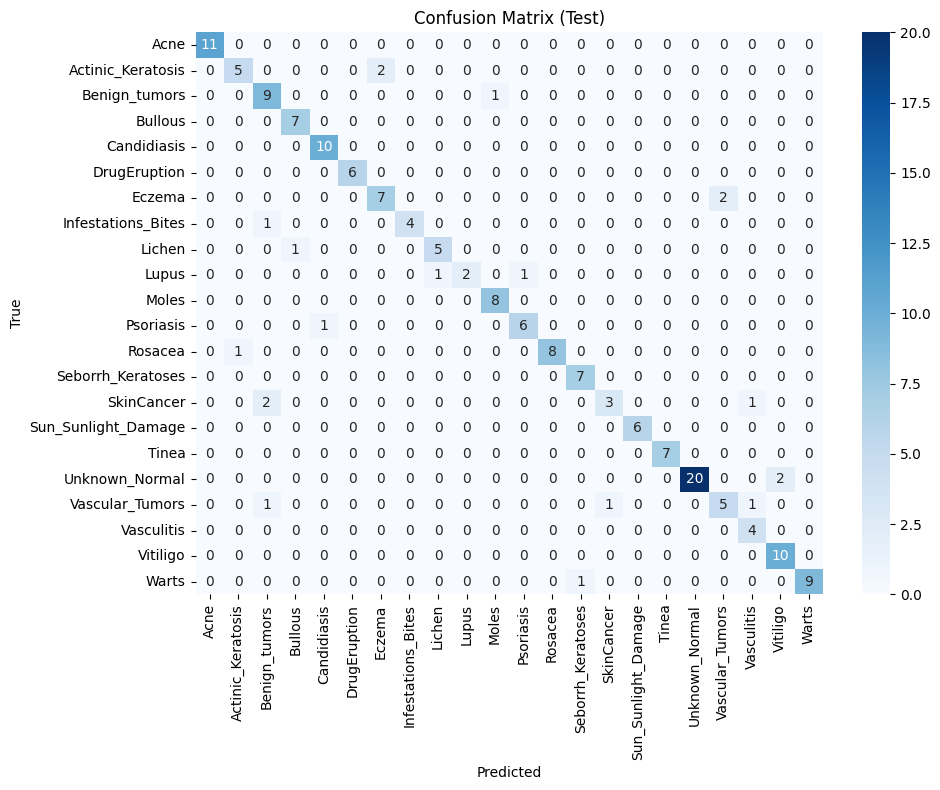

In [9]:
# ===================== 0) IMPORT =====================
import os
import numpy as np
import torch
import torch.nn as nn
from collections import OrderedDict

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast
from tqdm.auto import tqdm

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ===================== 1) CONFIG =====================
CKPT_PATH = r"E:\archive\PiplineCode pretrain=True\mobilenetv3_fulloption_imagenet.pth"  # <-- sửa path file đã train MobileNetV3
TEST_DIR  = r"E:\archive\SkinDisease\AnhTest"                                              # <-- sửa path folder test

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===================== 2) TRANSFORM TEST =====================
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# ===================== 3) LOAD TEST DATA (ImageFolder) =====================
if not os.path.isdir(TEST_DIR):
    raise FileNotFoundError(f"TEST_DIR không tồn tại: {TEST_DIR}")

test_ds = datasets.ImageFolder(TEST_DIR, transform=test_tfms)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda")
)

class_names = list(test_ds.classes)
print("Test classes (theo ImageFolder):", class_names)
print("Num test samples:", len(test_ds))

# ===================== 4) HÀM TRÍCH STATE_DICT (CHỊU NHIỀU FORMAT) =====================
def strip_prefix(state_dict, prefixes=("module.", "model.", "net.", "backbone.")):
    new_sd = OrderedDict()
    for k, v in state_dict.items():
        nk = k
        for p in prefixes:
            if nk.startswith(p):
                nk = nk[len(p):]
        new_sd[nk] = v
    return new_sd

def extract_state_dict(ckpt_obj):
    # Case A: torch.save(model, path) => ckpt là nn.Module
    if isinstance(ckpt_obj, nn.Module):
        return ckpt_obj.state_dict()

    # Case B: checkpoint dict chứa state_dict ở key phổ biến
    if isinstance(ckpt_obj, dict):
        for key in ["state_dict", "model_state_dict", "model_state", "model", "net", "network", "weights"]:
            if key in ckpt_obj:
                v = ckpt_obj[key]
                if isinstance(v, nn.Module):
                    return v.state_dict()
                if isinstance(v, dict):
                    return v

        # Case C: torch.save(model.state_dict(), path) => ckpt chính là state_dict
        if len(ckpt_obj) > 0 and all(torch.is_tensor(v) for v in ckpt_obj.values()):
            return ckpt_obj

    raise ValueError(
        f"Không trích được state_dict. type={type(ckpt_obj)}; "
        f"keys={list(ckpt_obj.keys())[:30] if isinstance(ckpt_obj, dict) else 'N/A'}"
    )

def infer_num_classes_from_state_dict(sd):
    # MobileNetV3 classifier thường kết thúc bằng lớp Linear: "classifier.3.weight" (large/small)
    candidates = [
        "classifier.3.weight",
        "classifier.4.weight",   # phòng khi custom khác
        "classifier.weight",     # một số code tự gán classifier = Linear(...)
        "fc.weight"
    ]
    for k in candidates:
        if k in sd and hasattr(sd[k], "shape") and len(sd[k].shape) == 2:
            return int(sd[k].shape[0])
    return None

# ===================== 5) LOAD CHECKPOINT + BUILD MODEL (MOBILENET V3 LARGE) =====================
if not os.path.isfile(CKPT_PATH):
    raise FileNotFoundError(f"CKPT_PATH không tồn tại: {CKPT_PATH}")

ckpt = torch.load(CKPT_PATH, map_location=device)
print("Checkpoint type:", type(ckpt))

# Nếu ckpt là cả model => dùng luôn
if isinstance(ckpt, nn.Module):
    model = ckpt
    model.to(device).eval()
    print("Loaded full model object from checkpoint.")
else:
    sd = extract_state_dict(ckpt)
    sd = strip_prefix(sd)

    inferred_classes = infer_num_classes_from_state_dict(sd)
    num_classes = inferred_classes if inferred_classes is not None else len(class_names)

    # build MobileNetV3 Large đúng số lớp
    model = models.mobilenet_v3_large(weights=None)

    # thay lớp cuối trong classifier: thường là index 3 (Linear)
    if isinstance(model.classifier, nn.Sequential):
        last_linear_idx = None
        for i in range(len(model.classifier) - 1, -1, -1):
            if isinstance(model.classifier[i], nn.Linear):
                last_linear_idx = i
                break
        if last_linear_idx is None:
            raise RuntimeError("Không tìm thấy nn.Linear trong model.classifier của MobileNetV3.")
        in_features = model.classifier[last_linear_idx].in_features
        model.classifier[last_linear_idx] = nn.Linear(in_features, num_classes)
    else:
        # fallback hiếm gặp
        raise RuntimeError("model.classifier không phải nn.Sequential (format lạ).")

    msg = model.load_state_dict(sd, strict=False)
    model.to(device).eval()

    print(f"Built MobileNetV3-Large with num_classes = {num_classes}")
    if len(msg.missing_keys) or len(msg.unexpected_keys):
        print("Missing keys (first 20):", msg.missing_keys[:20], "..." if len(msg.missing_keys) > 20 else "")
        print("Unexpected keys (first 20):", msg.unexpected_keys[:20], "..." if len(msg.unexpected_keys) > 20 else "")

# nếu checkpoint có lưu class_names thì ưu tiên dùng cho report (để khớp thứ tự lúc train)
# (MobileNetV3 không có model.fc nên mình lấy out_features từ Linear cuối trong classifier)
def get_out_features_mnv3(m):
    if isinstance(m.classifier, nn.Sequential):
        for i in range(len(m.classifier) - 1, -1, -1):
            if isinstance(m.classifier[i], nn.Linear):
                return m.classifier[i].out_features
    return None

if isinstance(ckpt, dict) and "class_names" in ckpt and isinstance(ckpt["class_names"], (list, tuple)):
    out_c = get_out_features_mnv3(model) or len(class_names)
    if len(ckpt["class_names"]) == out_c:
        class_names = list(ckpt["class_names"])
        print("Using class_names from checkpoint.")

# ===================== 6) EVALUATE TEST (AMP + PROGRESS BAR) =====================
y_true, y_pred = [], []

use_amp = (device.type == "cuda")
with torch.no_grad():
    pbar = tqdm(test_loader, desc="Evaluate Test", leave=True)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(enabled=use_amp):
            logits = model(images)

        preds = torch.argmax(logits, dim=1)

        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ===================== 7) CLASSIFICATION REPORT =====================
print("\n===== CLASSIFICATION REPORT (TEST) =====")
out_c = get_out_features_mnv3(model)
if out_c is not None and len(class_names) != out_c:
    class_names = [f"Class_{i}" for i in range(out_c)]

print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

# ===================== 8) CONFUSION MATRIX + PLOT =====================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


B0

Device: cuda
Test classes: ['Acne', 'Actinic_Keratosis', 'Benign_tumors', 'Bullous', 'Candidiasis', 'DrugEruption', 'Eczema', 'Infestations_Bites', 'Lichen', 'Lupus', 'Moles', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'SkinCancer', 'Sun_Sunlight_Damage', 'Tinea', 'Unknown_Normal', 'Vascular_Tumors', 'Vasculitis', 'Vitiligo', 'Warts']
Num test samples: 179
Checkpoint type: <class 'collections.OrderedDict'>
Built EfficientNet-b0 (efficientnet_pytorch) with num_classes = 22


Evaluate Test (EffNet-B0): 100%|██████████| 6/6 [00:03<00:00,  1.58it/s]



===== CLASSIFICATION REPORT (TEST) - EfficientNet-B0 =====
                     precision    recall  f1-score   support

               Acne     1.0000    1.0000    1.0000        11
  Actinic_Keratosis     1.0000    0.8571    0.9231         7
      Benign_tumors     0.8000    0.8000    0.8000        10
            Bullous     0.8750    1.0000    0.9333         7
        Candidiasis     1.0000    1.0000    1.0000        10
       DrugEruption     0.7500    1.0000    0.8571         6
             Eczema     0.7500    1.0000    0.8571         9
 Infestations_Bites     0.8000    0.8000    0.8000         5
             Lichen     0.8571    1.0000    0.9231         6
              Lupus     1.0000    0.5000    0.6667         4
              Moles     0.8889    1.0000    0.9412         8
          Psoriasis     0.8333    0.7143    0.7692         7
            Rosacea     1.0000    1.0000    1.0000         9
  Seborrh_Keratoses     0.8333    0.7143    0.7692         7
         SkinCancer     

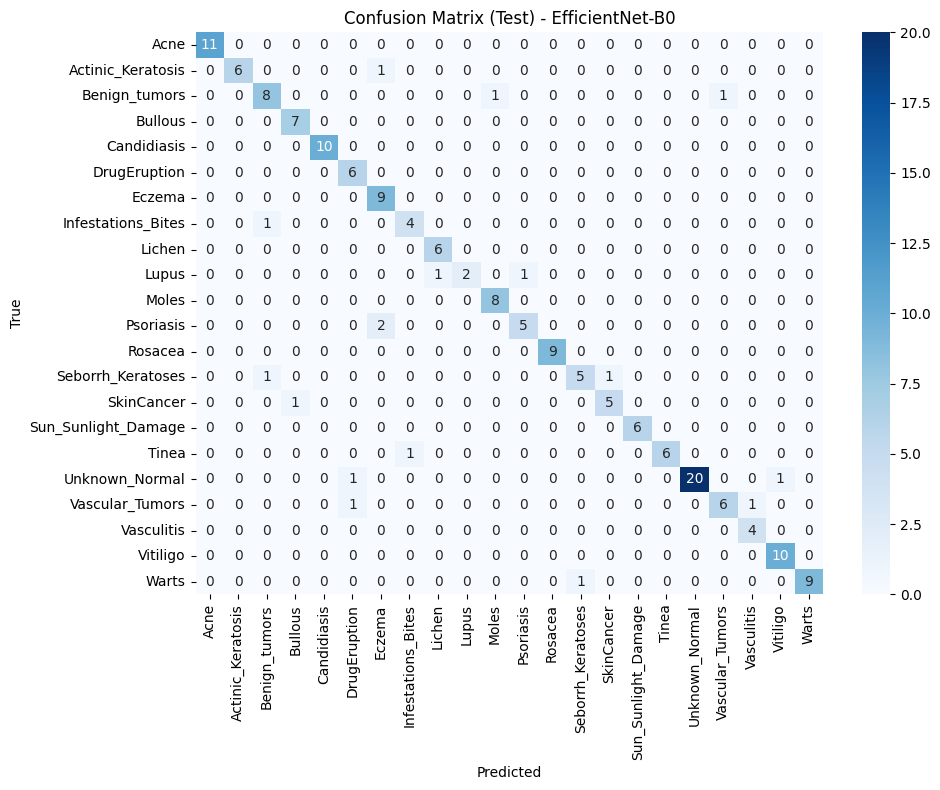

In [16]:
# ===================== 0) IMPORT =====================
import os
import numpy as np
import torch
import torch.nn as nn
from collections import OrderedDict

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from efficientnet_pytorch import EfficientNet   # <<< QUAN TRỌNG

# ===================== 1) CONFIG =====================
CKPT_PATH = r"E:\archive\PiplineCode pretrain=True\efficientnet_b0_pretrained_fulloption.pth"  # <-- ckpt B0
TEST_DIR  = r"E:\archive\SkinDisease\AnhTest"

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===================== 2) TRANSFORM TEST =====================
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# ===================== 3) LOAD TEST DATA =====================
if not os.path.isdir(TEST_DIR):
    raise FileNotFoundError(f"TEST_DIR không tồn tại: {TEST_DIR}")

test_ds = datasets.ImageFolder(TEST_DIR, transform=test_tfms)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

class_names = list(test_ds.classes)
print("Test classes:", class_names)
print("Num test samples:", len(test_ds))

# ===================== 4) LOAD STATE_DICT (CHỊU NHIỀU FORMAT) =====================
def strip_prefix(state_dict, prefixes=("module.", "model.", "net.", "backbone.")):
    new_sd = OrderedDict()
    for k, v in state_dict.items():
        nk = k
        for p in prefixes:
            if nk.startswith(p):
                nk = nk[len(p):]
        new_sd[nk] = v
    return new_sd

def extract_state_dict(ckpt_obj):
    if isinstance(ckpt_obj, nn.Module):
        return ckpt_obj.state_dict()

    if isinstance(ckpt_obj, dict):
        for key in ["state_dict", "model_state_dict", "model_state", "model", "net", "network", "weights"]:
            if key in ckpt_obj:
                v = ckpt_obj[key]
                if isinstance(v, nn.Module):
                    return v.state_dict()
                if isinstance(v, dict):
                    return v

        if len(ckpt_obj) > 0 and all(torch.is_tensor(v) for v in ckpt_obj.values()):
            return ckpt_obj

    raise ValueError("Không trích được state_dict từ checkpoint.")

def infer_num_classes_effnet_pytorch(sd):
    # efficientnet_pytorch dùng _fc cho classifier
    for k in ["_fc.weight", "fc.weight", "classifier.weight"]:
        if k in sd and hasattr(sd[k], "shape") and len(sd[k].shape) == 2:
            return int(sd[k].shape[0])
    return None

# ===================== 5) LOAD CHECKPOINT + BUILD EFFNET-PYTORCH B0 =====================
if not os.path.isfile(CKPT_PATH):
    raise FileNotFoundError(f"CKPT_PATH không tồn tại: {CKPT_PATH}")

# nếu PyTorch bạn hỗ trợ, dùng weights_only=True để hết warning
try:
    ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=True)
except TypeError:
    ckpt = torch.load(CKPT_PATH, map_location=device)

print("Checkpoint type:", type(ckpt))

if isinstance(ckpt, nn.Module):
    model = ckpt
    model.to(device).eval()
    print("Loaded full model object from checkpoint.")
else:
    sd = strip_prefix(extract_state_dict(ckpt))
    inferred = infer_num_classes_effnet_pytorch(sd)
    num_classes = inferred if inferred is not None else len(class_names)

    # build đúng kiểu EfficientNet của efficientnet_pytorch
    model = EfficientNet.from_name("efficientnet-b0")
    model._fc = nn.Linear(model._fc.in_features, num_classes)

    msg = model.load_state_dict(sd, strict=False)
    model.to(device).eval()

    print(f"Built EfficientNet-b0 (efficientnet_pytorch) with num_classes = {num_classes}")
    if len(msg.missing_keys) or len(msg.unexpected_keys):
        print("Missing keys (first 20):", msg.missing_keys[:20], "..." if len(msg.missing_keys) > 20 else "")
        print("Unexpected keys (first 20):", msg.unexpected_keys[:20], "..." if len(msg.unexpected_keys) > 20 else "")

# ===================== 6) EVALUATE (AMP + PROGRESS BAR) =====================
y_true, y_pred = [], []
use_amp = (device.type == "cuda")

with torch.no_grad():
    pbar = tqdm(test_loader, desc="Evaluate Test (EffNet-B0)", leave=True)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # autocast mới
        if use_amp:
            with torch.amp.autocast("cuda"):
                logits = model(images)
        else:
            logits = model(images)

        preds = torch.argmax(logits, dim=1)
        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ===================== 7) REPORT =====================
print("\n===== CLASSIFICATION REPORT (TEST) - EfficientNet-B0 =====")
out_c = model._fc.out_features if hasattr(model, "_fc") else len(class_names)
if len(class_names) != out_c:
    class_names = [f"Class_{i}" for i in range(out_c)]

print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

# ===================== 8) CONFUSION MATRIX =====================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Test) - EfficientNet-B0")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


B4

Device: cuda
Test classes: ['Acne', 'Actinic_Keratosis', 'Benign_tumors', 'Bullous', 'Candidiasis', 'DrugEruption', 'Eczema', 'Infestations_Bites', 'Lichen', 'Lupus', 'Moles', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'SkinCancer', 'Sun_Sunlight_Damage', 'Tinea', 'Unknown_Normal', 'Vascular_Tumors', 'Vasculitis', 'Vitiligo', 'Warts']
Num test samples: 179
Checkpoint type: <class 'collections.OrderedDict'>
Built EfficientNet-b4 (efficientnet_pytorch) with num_classes = 22


Evaluate Test (EffNet-B4): 100%|██████████| 6/6 [00:03<00:00,  1.55it/s]



===== CLASSIFICATION REPORT (TEST) - EfficientNet-B4 =====
                     precision    recall  f1-score   support

               Acne     0.8333    0.9091    0.8696        11
  Actinic_Keratosis     0.8333    0.7143    0.7692         7
      Benign_tumors     0.9000    0.9000    0.9000        10
            Bullous     0.6364    1.0000    0.7778         7
        Candidiasis     1.0000    1.0000    1.0000        10
       DrugEruption     0.5455    1.0000    0.7059         6
             Eczema     0.8571    0.6667    0.7500         9
 Infestations_Bites     1.0000    0.8000    0.8889         5
             Lichen     0.7143    0.8333    0.7692         6
              Lupus     0.8000    1.0000    0.8889         4
              Moles     0.8889    1.0000    0.9412         8
          Psoriasis     0.8333    0.7143    0.7692         7
            Rosacea     1.0000    0.8889    0.9412         9
  Seborrh_Keratoses     1.0000    1.0000    1.0000         7
         SkinCancer     

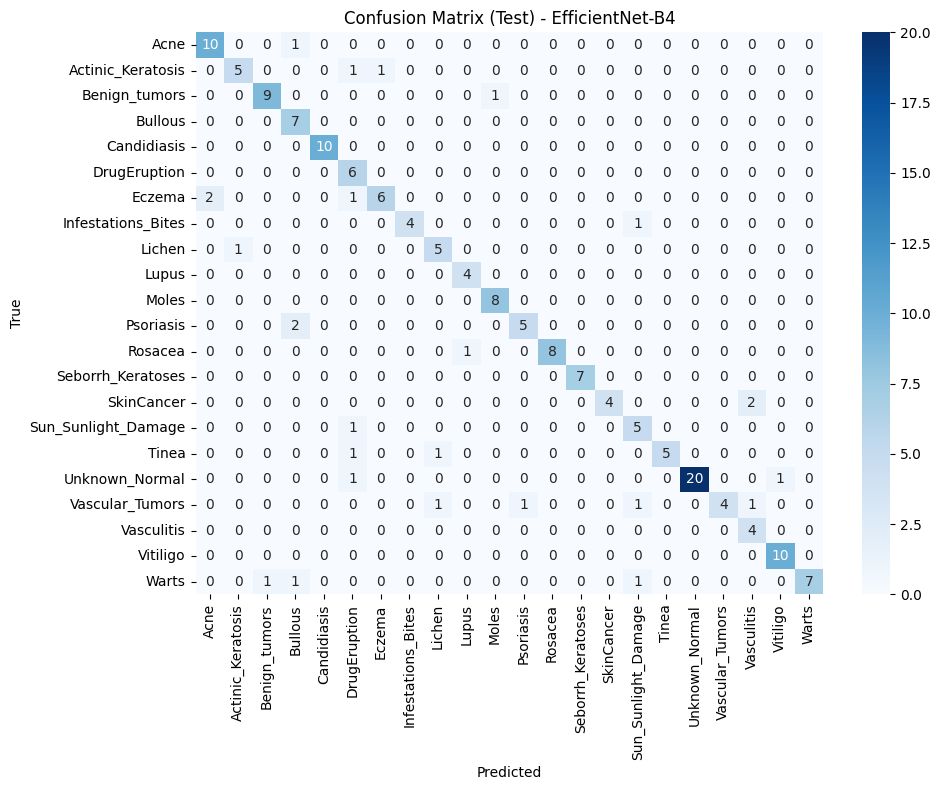

In [15]:
# ===================== 0) IMPORT =====================
import os
import numpy as np
import torch
import torch.nn as nn
from collections import OrderedDict

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from efficientnet_pytorch import EfficientNet   # <<< QUAN TRỌNG

# ===================== 1) CONFIG =====================
CKPT_PATH = r"E:\archive\PiplineCode pretrain=True\efficientnet_b4_pretrained_fulloption.pth"
TEST_DIR  = r"E:\archive\SkinDisease\AnhTest"

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===================== 2) TRANSFORM TEST =====================
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# ===================== 3) LOAD TEST DATA =====================
if not os.path.isdir(TEST_DIR):
    raise FileNotFoundError(f"TEST_DIR không tồn tại: {TEST_DIR}")

test_ds = datasets.ImageFolder(TEST_DIR, transform=test_tfms)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

class_names = list(test_ds.classes)
print("Test classes:", class_names)
print("Num test samples:", len(test_ds))

# ===================== 4) LOAD STATE_DICT (CHỊU NHIỀU FORMAT) =====================
def strip_prefix(state_dict, prefixes=("module.", "model.", "net.", "backbone.")):
    new_sd = OrderedDict()
    for k, v in state_dict.items():
        nk = k
        for p in prefixes:
            if nk.startswith(p):
                nk = nk[len(p):]
        new_sd[nk] = v
    return new_sd

def extract_state_dict(ckpt_obj):
    if isinstance(ckpt_obj, nn.Module):
        return ckpt_obj.state_dict()

    if isinstance(ckpt_obj, dict):
        for key in ["state_dict", "model_state_dict", "model_state", "model", "net", "network", "weights"]:
            if key in ckpt_obj:
                v = ckpt_obj[key]
                if isinstance(v, nn.Module):
                    return v.state_dict()
                if isinstance(v, dict):
                    return v

        if len(ckpt_obj) > 0 and all(torch.is_tensor(v) for v in ckpt_obj.values()):
            return ckpt_obj

    raise ValueError("Không trích được state_dict từ checkpoint.")

def infer_num_classes_effnet_pytorch(sd):
    # efficientnet_pytorch dùng _fc cho classifier
    for k in ["_fc.weight", "fc.weight", "classifier.weight"]:
        if k in sd and hasattr(sd[k], "shape") and len(sd[k].shape) == 2:
            return int(sd[k].shape[0])
    return None

# ===================== 5) LOAD CHECKPOINT + BUILD EFFNET-PYTORCH B4 =====================
if not os.path.isfile(CKPT_PATH):
    raise FileNotFoundError(f"CKPT_PATH không tồn tại: {CKPT_PATH}")

# nếu PyTorch bạn hỗ trợ, dùng weights_only=True để hết warning
try:
    ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=True)
except TypeError:
    ckpt = torch.load(CKPT_PATH, map_location=device)

print("Checkpoint type:", type(ckpt))

if isinstance(ckpt, nn.Module):
    model = ckpt
    model.to(device).eval()
    print("Loaded full model object from checkpoint.")
else:
    sd = strip_prefix(extract_state_dict(ckpt))
    inferred = infer_num_classes_effnet_pytorch(sd)
    num_classes = inferred if inferred is not None else len(class_names)

    # build đúng kiểu EfficientNet của efficientnet_pytorch
    model = EfficientNet.from_name("efficientnet-b4")
    model._fc = nn.Linear(model._fc.in_features, num_classes)

    msg = model.load_state_dict(sd, strict=False)  # thường sẽ khớp gần như hết
    model.to(device).eval()

    print(f"Built EfficientNet-b4 (efficientnet_pytorch) with num_classes = {num_classes}")
    if len(msg.missing_keys) or len(msg.unexpected_keys):
        print("Missing keys (first 20):", msg.missing_keys[:20], "..." if len(msg.missing_keys) > 20 else "")
        print("Unexpected keys (first 20):", msg.unexpected_keys[:20], "..." if len(msg.unexpected_keys) > 20 else "")

# ===================== 6) EVALUATE (AMP + PROGRESS BAR) =====================
y_true, y_pred = [], []
use_amp = (device.type == "cuda")

with torch.no_grad():
    pbar = tqdm(test_loader, desc="Evaluate Test (EffNet-B4)", leave=True)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # autocast mới
        if use_amp:
            with torch.amp.autocast("cuda"):
                logits = model(images)
        else:
            logits = model(images)

        preds = torch.argmax(logits, dim=1)
        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ===================== 7) REPORT =====================
print("\n===== CLASSIFICATION REPORT (TEST) - EfficientNet-B4 =====")
# bảo vệ nếu lệch số lớp
out_c = model._fc.out_features if hasattr(model, "_fc") else len(class_names)
if len(class_names) != out_c:
    class_names = [f"Class_{i}" for i in range(out_c)]

print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

# ===================== 8) CONFUSION MATRIX =====================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Test) - EfficientNet-B4")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


Vgg16

Device: cuda
Test classes: ['Acne', 'Actinic_Keratosis', 'Benign_tumors', 'Bullous', 'Candidiasis', 'DrugEruption', 'Eczema', 'Infestations_Bites', 'Lichen', 'Lupus', 'Moles', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'SkinCancer', 'Sun_Sunlight_Damage', 'Tinea', 'Unknown_Normal', 'Vascular_Tumors', 'Vasculitis', 'Vitiligo', 'Warts']
Num test samples: 179
Checkpoint type: <class 'collections.OrderedDict'>
Built VGG16 with num_classes = 22


Evaluate Test (VGG16): 100%|██████████| 6/6 [00:04<00:00,  1.43it/s]



===== CLASSIFICATION REPORT (TEST) - VGG16 =====
                     precision    recall  f1-score   support

               Acne     1.0000    0.9091    0.9524        11
  Actinic_Keratosis     0.7500    0.8571    0.8000         7
      Benign_tumors     0.7692    1.0000    0.8696        10
            Bullous     0.7000    1.0000    0.8235         7
        Candidiasis     1.0000    1.0000    1.0000        10
       DrugEruption     1.0000    1.0000    1.0000         6
             Eczema     1.0000    0.7778    0.8750         9
 Infestations_Bites     0.8333    1.0000    0.9091         5
             Lichen     0.6250    0.8333    0.7143         6
              Lupus     0.5000    0.2500    0.3333         4
              Moles     0.8750    0.8750    0.8750         8
          Psoriasis     1.0000    1.0000    1.0000         7
            Rosacea     1.0000    0.8889    0.9412         9
  Seborrh_Keratoses     1.0000    0.7143    0.8333         7
         SkinCancer     1.0000    

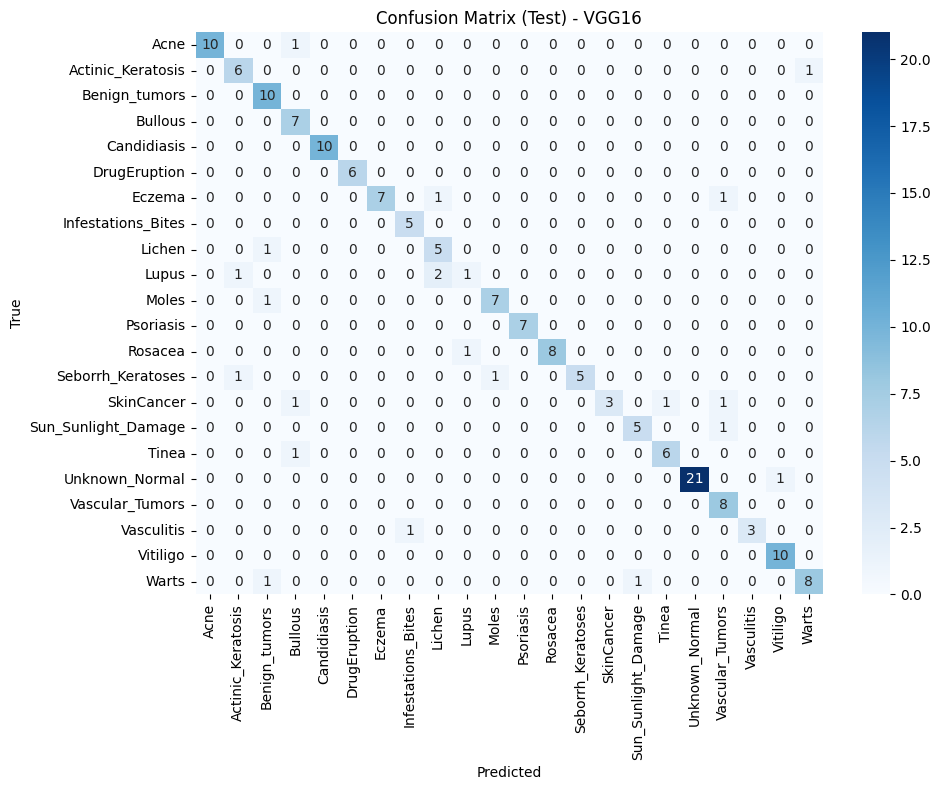

In [17]:
# ===================== 0) IMPORT =====================
import os
import numpy as np
import torch
import torch.nn as nn
from collections import OrderedDict

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ===================== 1) CONFIG =====================
CKPT_PATH = r"E:\archive\PiplineCode pretrain=True\vgg16_pretrained_fulloption.pth"  # <-- sửa path ckpt VGG16
TEST_DIR  = r"E:\archive\SkinDisease\AnhTest"                                        # <-- sửa path test

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===================== 2) TRANSFORM TEST =====================
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# ===================== 3) LOAD TEST DATA =====================
if not os.path.isdir(TEST_DIR):
    raise FileNotFoundError(f"TEST_DIR không tồn tại: {TEST_DIR}")

test_ds = datasets.ImageFolder(TEST_DIR, transform=test_tfms)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

class_names = list(test_ds.classes)
print("Test classes:", class_names)
print("Num test samples:", len(test_ds))

# ===================== 4) HÀM TRÍCH STATE_DICT (CHỊU NHIỀU FORMAT) =====================
def strip_prefix(state_dict, prefixes=("module.", "model.", "net.", "backbone.")):
    new_sd = OrderedDict()
    for k, v in state_dict.items():
        nk = k
        for p in prefixes:
            if nk.startswith(p):
                nk = nk[len(p):]
        new_sd[nk] = v
    return new_sd

def extract_state_dict(ckpt_obj):
    if isinstance(ckpt_obj, nn.Module):
        return ckpt_obj.state_dict()

    if isinstance(ckpt_obj, dict):
        for key in ["state_dict", "model_state_dict", "model_state", "model", "net", "network", "weights"]:
            if key in ckpt_obj:
                v = ckpt_obj[key]
                if isinstance(v, nn.Module):
                    return v.state_dict()
                if isinstance(v, dict):
                    return v

        if len(ckpt_obj) > 0 and all(torch.is_tensor(v) for v in ckpt_obj.values()):
            return ckpt_obj

    raise ValueError("Không trích được state_dict từ checkpoint.")

def infer_num_classes_from_state_dict(sd):
    # VGG16: lớp cuối classifier.6 là Linear
    for k in ["classifier.6.weight", "classifier.weight", "fc.weight"]:
        if k in sd and hasattr(sd[k], "shape") and len(sd[k].shape) == 2:
            return int(sd[k].shape[0])
    return None

# ===================== 5) LOAD CHECKPOINT + BUILD VGG16 =====================
if not os.path.isfile(CKPT_PATH):
    raise FileNotFoundError(f"CKPT_PATH không tồn tại: {CKPT_PATH}")

# nếu PyTorch hỗ trợ, dùng weights_only=True để giảm warning
try:
    ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=True)
except TypeError:
    ckpt = torch.load(CKPT_PATH, map_location=device)

print("Checkpoint type:", type(ckpt))

def get_out_features_vgg(m):
    if hasattr(m, "classifier") and isinstance(m.classifier, nn.Sequential):
        if isinstance(m.classifier[6], nn.Linear):
            return m.classifier[6].out_features
        # fallback: tìm Linear cuối
        for i in range(len(m.classifier) - 1, -1, -1):
            if isinstance(m.classifier[i], nn.Linear):
                return m.classifier[i].out_features
    return None

if isinstance(ckpt, nn.Module):
    model = ckpt
    model.to(device).eval()
    print("Loaded full model object from checkpoint.")
else:
    sd = strip_prefix(extract_state_dict(ckpt))

    inferred = infer_num_classes_from_state_dict(sd)
    num_classes = inferred if inferred is not None else len(class_names)

    model = models.vgg16(weights=None)

    # thay Linear cuối classifier.6
    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(in_features, num_classes)

    msg = model.load_state_dict(sd, strict=False)
    model.to(device).eval()

    print(f"Built VGG16 with num_classes = {num_classes}")
    if len(msg.missing_keys) or len(msg.unexpected_keys):
        print("Missing keys (first 20):", msg.missing_keys[:20], "..." if len(msg.missing_keys) > 20 else "")
        print("Unexpected keys (first 20):", msg.unexpected_keys[:20], "..." if len(msg.unexpected_keys) > 20 else "")

# ưu tiên class_names từ checkpoint nếu có
if isinstance(ckpt, dict) and "class_names" in ckpt and isinstance(ckpt["class_names"], (list, tuple)):
    out_c = get_out_features_vgg(model) or len(class_names)
    if len(ckpt["class_names"]) == out_c:
        class_names = list(ckpt["class_names"])
        print("Using class_names from checkpoint.")

# ===================== 6) EVALUATE (AMP + PROGRESS BAR) =====================
y_true, y_pred = [], []
use_amp = (device.type == "cuda")

with torch.no_grad():
    pbar = tqdm(test_loader, desc="Evaluate Test (VGG16)", leave=True)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if use_amp:
            with torch.amp.autocast("cuda"):
                logits = model(images)
        else:
            logits = model(images)

        preds = torch.argmax(logits, dim=1)
        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ===================== 7) REPORT =====================
print("\n===== CLASSIFICATION REPORT (TEST) - VGG16 =====")
out_c = get_out_features_vgg(model)
if out_c is not None and len(class_names) != out_c:
    class_names = [f"Class_{i}" for i in range(out_c)]

print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

# ===================== 8) CONFUSION MATRIX =====================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Test) - VGG16")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()
